In [ ]:
import kagglehub
import os

def download_datasets():
    # 1. Download Training Data (VGGFace2)
    #print("⬇️ Downloading Training Data (VGGFace2)...")
    # This downloads to the local Colab disk (Ephemera) - Very Fast
    #train_cache = kagglehub.dataset_download("yakhyokhuja/vggface2-112x112")
    #print(f"✅ Training Path: {train_cache}")

    # 2. Download Validation Data (LFW, etc.)
    print("⬇️ Downloading Validation Data (LFW/AgeDB)...")
    val_cache = kagglehub.dataset_download("yakhyokhuja/agedb-30-calfw-cplfw-lfw-aligned-112x112")
    print(f"✅ Validation Path: {val_cache}")

    return val_cache

# Execute and store paths in global variables
VAL_DATA_PATH = download_datasets()

⬇️ Downloading Validation Data (LFW/AgeDB)...


100%|██████████| 1.31G/1.31G [00:13<00:00, 107MB/s]

Extracting files...


✅ Validation Path: /root/.cache/kagglehub/datasets/yakhyokhuja/agedb-30-calfw-cplfw-lfw-aligned-112x112/versions/1


In [ ]:
#TRAIN_DATA_PATH = "/root/.cache/kagglehub/datasets/yakhyokhuja/vggface2-112x112/versions/1/vggface2_112x112"
VAL_DATA_PATH = "/root/.cache/kagglehub/datasets/yakhyokhuja/agedb-30-calfw-cplfw-lfw-aligned-112x112/versions/1/val"

# LookAlike (Find your twin with SNN)
This project was meant to be about Facial Recognition, while I faced some hardware based issues I decided to work on an implementation of a model for finding the lookalike of a given face using the VGGFace2 Dataset.

### 1st Step: Loading the dataset (Triplet Generator)
Standard datasets return (Image, Label) my dataset needs to return (Anchor, Positive, Negative). This code is based on the [Triplet Loss](https://medium.com/analytics-vidhya/triplet-loss-b9da35be21b8) method that learns similarity rather than just Classification. We need to write a custom PyTorch Dataset class that does this on the fly.
![image.png](https://miro.medium.com/v2/resize:fit:1100/format:webp/1*rDBbSTCvh0xnu2otaW9cyw.png)

In [ ]:
# ==== HELPER FUNCTIONS FOR VISUALIZATION ====
import matplotlib.pyplot as plt
import numpy as np
import torchvision

# Helper to un-normalize and plot
def imshow(inp, title=None):
    """Imshow for Tensor."""
    inp = inp.cpu().numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.axis('off')

def visualize_training_triplets(loader, num_triplets=3):
    """Shows Anchor, Positive, Negative from training set"""
    data_iter = iter(loader)
    anchor, positive, negative = next(data_iter)

    plt.figure(figsize=(12, 4*num_triplets))
    for i in range(num_triplets):
        # Anchor
        plt.subplot(num_triplets, 3, i*3 + 1)
        imshow(anchor[i], title=f"Anchor {i}")
        # Positive
        plt.subplot(num_triplets, 3, i*3 + 2)
        imshow(positive[i], title=f"Positive {i}")
        # Negative
        plt.subplot(num_triplets, 3, i*3 + 3)
        imshow(negative[i], title=f"Negative {i}")
    plt.tight_layout()
    plt.show()

def visualize_validation_pairs(loader, model, device, num_pairs=5):
    """Shows pairs from LFW and their predicted distances"""
    data_iter = iter(loader)
    img1, img2, label = next(data_iter)
    img1, img2 = img1.to(device), img2.to(device)

    # Get predictions
    model.eval()
    with torch.no_grad():
        emb1 = model(img1)
        emb2 = model(img2)
        dists = torch.nn.functional.pairwise_distance(emb1, emb2)

    plt.figure(figsize=(10, 3*num_pairs))
    for i in range(num_pairs):
        # Image 1
        plt.subplot(num_pairs, 2, i*2 + 1)
        imshow(img1[i])

        # Image 2
        plt.subplot(num_pairs, 2, i*2 + 2)
        is_same = "MATCH" if label[i] == 1 else "DIFF"
        color = "green" if label[i] == 1 else "red"
        imshow(img2[i], title=f"GT: {is_same} | Dist: {dists[i]:.3f}")
    plt.show()
    model.train() # Switch back to train mode

In [ ]:
def evaluate_lfw_accuracy(model, loader, device):
  model.eval()
  distances = []
  labels = []

  with torch.no_grad():
    for img1, img2, label in loader:
      img1, img2 = img1.to(device), img2.to(device)
      emb1 = model(img1)
      emb2 = model(img2)
      dist = torch.nn.functional.pairwise_distance(emb1, emb2)
      distances.extend(dist.cpu().numpy())
      labels.extend(label.cpu().numpy())

  distances = np.array(distances)
  labels = np.array(labels)

  best_acc = 0

  for threshold in np.arange(0.0, 2.0, 0.05):
    preds = (distances < threshold).astype(int)
    acc = np.mean((preds == labels).astype(int))
    if acc > best_acc:
      best_acc = acc
  model.train() # Don't forget to switch back
  return best_acc

In [ ]:
import numpy as np
import torch

class EarlyStopping:
    def __init__(self, patience=5, verbose=False, delta=0):
        """
        Args:
            patience (int): How long to wait after last time validation loss improved.
            verbose (bool): If True, prints a message for each validation loss improvement.
            delta (float): Minimum change in the monitored quantity to qualify as an improvement.
        """
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.delta = delta

    def __call__(self, val_acc, model, path):
        score = val_acc

        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_acc, model, path)
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.verbose:
                print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_acc, model, path)
            self.counter = 0

    def save_checkpoint(self, val_acc, model, path):
        '''Saves model when validation accuracy increases.'''
        if self.verbose:
            print(f'Validation Accuracy increased ({self.best_score:.4f} --> {val_acc:.4f}).  Saving model ...')
        torch.save(model.state_dict(), path)

#### Visualize Pairs in Training Data

In [ ]:
import os
import random
import torch
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

class TripletFaceDataset(Dataset):
    def __init__(self, root_dir, split="train", val_split_ratio=0.1):
        self.root_dir = root_dir
        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

        # Get all identity folder names sorted (id_2, id_3, ...)
        all_identities = sorted([d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))])

        # Calculate split index
        split_idx = int(len(all_identities) * (1 - val_split_ratio))

        if split == "train":
            self.identities = all_identities[:split_idx]
        else:
            self.identities = all_identities[split_idx:]

        # Filter out identities with fewer than 2 images (need 2 for Anchor+Positive)
        self.valid_identities = []
        for identity in self.identities:
            img_path = os.path.join(root_dir, identity)
            if len(os.listdir(img_path)) > 1:
                self.valid_identities.append(identity)

        print(f"[{split.upper()}] Loaded {len(self.valid_identities)} identities.")

    def __len__(self):
        return len(self.valid_identities)

    def __getitem__(self, idx):
        # 1. Anchor & Positive (Same Person)
        anchor_id = self.valid_identities[idx]
        anchor_folder = os.path.join(self.root_dir, anchor_id)
        anchor_images = os.listdir(anchor_folder)

        a_img_name, p_img_name = random.sample(anchor_images, 2)

        def load_img(path):
            img = Image.open(path).convert('RGB')
            return self.transform(img)

        neg_images = []
        for _ in range(3):
          neg_id = random.choice(self.valid_identities)
          while neg_id == anchor_id:
              neg_id = random.choice(self.valid_identities)
          n_img_name = random.choice(os.listdir(os.path.join(self.root_dir, neg_id)))
          neg_images.append(load_img(os.path.join(self.root_dir, neg_id, n_img_name)))

        anchor = load_img(os.path.join(anchor_folder, a_img_name))
        positive = load_img(os.path.join(anchor_folder, p_img_name))

        return anchor, positive, neg_images[0]

In [ ]:
train_dataset = TripletFaceDataset(root_dir=TRAIN_DATA_PATH, split="train")
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
print("Visualizing Training Triplets...")
visualize_training_triplets(train_loader)

NameError: name 'TRAIN_DATA_PATH' is not defined

#### Visualize Validation Pairs

In [ ]:
import os
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as transforms

class LFWPairsDataset(Dataset):
    def __init__(self, root_dir, dataset_name="lfw"):
        self.root_dir = root_dir
        self.dataset_name = dataset_name
        self.transform = transforms.Compose([
            transforms.Resize((112, 112)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

        # 1. Locate the Annotation File
        candidates = [
            os.path.join(root_dir, f"{dataset_name}_ann.txt"),
            os.path.join(root_dir, f"{dataset_name}_112x112", f"{dataset_name}_ann.txt")
        ]

        self.ann_file = None
        for c in candidates:
            if os.path.exists(c):
                self.ann_file = c
                break

        if not self.ann_file:
            print(f"❌ Error: Could not find annotation file for {dataset_name}")
            self.pairs = []
            return

        # 2. Parse Pairs Directly
        self.pairs = []
        print(f"📂 Reading Pairs from: {self.ann_file} ...")

        with open(self.ann_file, 'r') as f:
            for line in f:
                parts = line.strip().split()
                # Format appears to be: Label Path1 Path2
                # e.g., "1 lfw_112x112/0.bmp lfw_112x112/1.bmp"
                if len(parts) >= 3:
                    try:
                        label = int(parts[0]) # Label is the FIRST item
                        path1 = parts[1]
                        path2 = parts[2]
                        self.pairs.append((path1, path2, label))
                    except ValueError:
                        continue # Skip malformed lines

        print(f"   ✅ Loaded {len(self.pairs)} pairs for validation.")

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        path1, path2, label = self.pairs[idx]

        # Construct full paths (paths in text file are relative to val/ root)
        f1 = os.path.join(self.root_dir, path1)
        f2 = os.path.join(self.root_dir, path2)

        try:
            img1 = Image.open(f1).convert('RGB')
            img2 = Image.open(f2).convert('RGB')
        except Exception as e:
            # Return black image on error to prevent crash
            img1 = Image.new('RGB', (112, 112))
            img2 = Image.new('RGB', (112, 112))

        if self.transform:
            img1 = self.transform(img1)
            img2 = self.transform(img2)

        return img1, img2, torch.tensor(label, dtype=torch.float32)

# Create the Loader
# Ensure VAL_DATA_PATH is set from the download step
VAL_ROOT = os.path.join(VAL_DATA_PATH)
lfw_dataset = LFWPairsDataset(VAL_ROOT, dataset_name="lfw")
lfw_loader = DataLoader(lfw_dataset, batch_size=32, shuffle=False)

📂 Reading Pairs from: /root/.cache/kagglehub/datasets/yakhyokhuja/agedb-30-calfw-cplfw-lfw-aligned-112x112/versions/1/val/lfw_ann.txt ...
   ✅ Loaded 6000 pairs for validation.


### SSN + EfficientNet
For this second step we will implement the choosen architecture.
#### General Architecture
The solution is to develop a model that is capable of comparing the similarity between an input face and the faces of the dataset to return the face that is the most similar to the input face. It's basically a sort of face recognition algorithm the only purpose here is to find your twin. The Algorithm should:
- detect the individuals face in an image
- produce for each isolated face, an identity vector à 64 dimensions representing it
- calculate the distance between the vectors associated to two distinct profiles
- and determine if the to face A associated vector is near to the one of an already identified face B from the dataset.

The core of this model is the aim to calculate a similarity which tells us how identical the face of an individual is to another. Because our aim is to find a look a like someone ressembling, individual A the most we won't train the model on individual A's face.

The architecture is siamese and inspired by EfficientNet.

In [ ]:
import torch
import torch.nn as nn
from torchvision import models

class SiameseNetwork_EffNet(nn.Module):
    def __init__(self):
        super(SiameseNetwork_EffNet, self).__init__()
        # Load EfficientNet-B0
        self.backbone = models.efficientnet_b0(weights='DEFAULT')

        # Replace classifier with embedding head
        input_feats = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Sequential(
            nn.Linear(input_feats, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, EMBEDDING_DIM)
        )

    def forward(self, x):
        # Forward pass
        x = self.backbone(x)
        # L2 Normalization (Crucial for Euclidean distance!)
        # This forces all vectors to lie on a hypersphere
        return torch.nn.functional.normalize(x, p=2, dim=1)

### Training Loop (SSN+EfficientNet)
This is where the magic happens. We will use TripletMarginLoss.
$$Loss=max(d(a,p)-d(a,n)+margin,0)$$

This forces the distance between the Anchor and Positive $(d(a,p))$ to be smaller than the distance between Anchor and Negative $(d(a,n))$ by at least the margin.

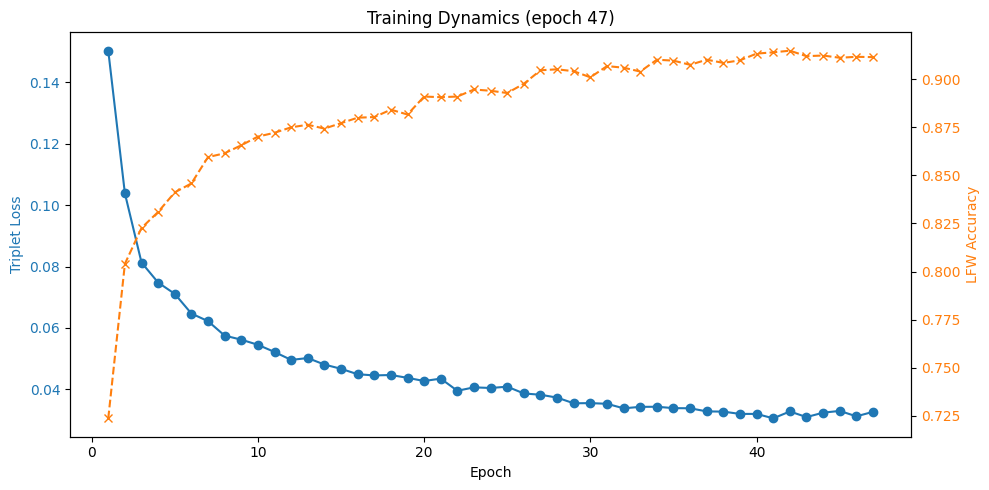

Epoch 47: Loss: 0.0326, Val Acc: 0.9115
EarlyStopping counter: 5 out of 5
Early stopping triggered! Model has stopped improving.


FileNotFoundError: [Errno 2] No such file or directory: 'best_lookalike_model.pth'

In [ ]:
from typing_extensions import evaluate_forward_ref
import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from IPython.display import clear_output
import matplotlib.pyplot as plt


early_stopper = EarlyStopping(patience=5, verbose=True)

history = {
    'train_loss': [],
    'val_acc': [],
    'epochs': []
}

BATCH_SIZE = 32         # Increased for stability
LEARNING_RATE = 0.0001  # Lowered (Critical!)
EPOCHS = 100             # Increased slightly
EMBEDDING_DIM = 128
MARGIN = 0.2            # Lowered (Critical!)
# --- Setup ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
SNN = SiameseNetwork_EffNet().to(device)

# --- KEY CHANGE: Use a Scheduler ---
optimizer = optim.Adam(SNN.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
criterion = nn.TripletMarginLoss(margin=MARGIN, p=2)

print("Starting Training with validation monitoring...")

for epoch in range(EPOCHS):
    SNN.train()
    total_loss = 0

    # Using TQDM for a nice progress bar
    loop = tqdm.tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")

    for anchor, positive, negative in loop:
        anchor, positive, negative = anchor.to(device), positive.to(device), negative.to(device)

        optimizer.zero_grad()

        # Get embeddings
        a_emb, p_emb, n_emb = SNN(anchor), SNN(positive), SNN(negative)

        # Calculate Loss
        loss = criterion(a_emb, p_emb, n_emb)

        # Backprop
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        loop.set_postfix(loss=loss.item())

    avg_train_loss = total_loss / len(train_loader)

    # VALIDATION PHASE
    val_acc = evaluate_lfw_accuracy(SNN, lfw_loader, device)

    history['train_loss'].append(avg_train_loss)
    history['val_acc'].append(val_acc)
    history['epochs'].append(epoch+1)

    scheduler.step(avg_train_loss)

    clear_output(wait=True)

    fig, ax1 = plt.subplots(figsize=(10, 5))

    # PLOT LOSS
    color = 'tab:blue'
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Triplet Loss', color=color)
    ax1.plot(history['epochs'], history['train_loss'], color=color, marker='o', label='Train Loss')
    ax1.tick_params(axis='y', labelcolor=color)

    # PLOT ACCURACY
    ax2 = ax1.twinx()
    color = 'tab:orange'
    ax2.set_ylabel('LFW Accuracy', color=color)
    ax2.plot(history['epochs'], history['val_acc'], color=color, marker='x', linestyle="--", label='Val Acc')
    ax2.tick_params(axis='y', labelcolor=color)
    plt.title(f"Training Dynamics (epoch {epoch+1})")
    fig.tight_layout()
    plt.show()

    print(f"Epoch {epoch+1}: Loss: {avg_train_loss:.4f}, Val Acc: {val_acc:.4f}")

    early_stopper(val_acc, SNN, 'best_effnet_model.pth')

    if early_stopper.early_stop:
        print("Early stopping triggered! Model has stopped improving.")
        break

Loaded best model weights!
Visualizing Validation Pairs...


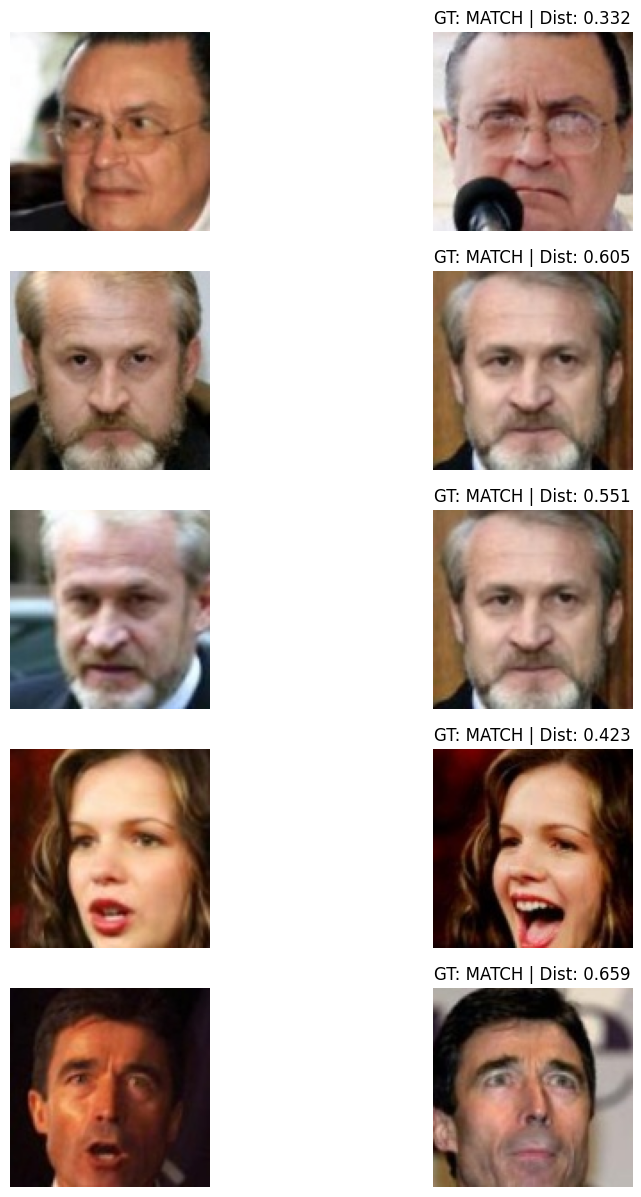

In [ ]:
SNN.load_state_dict(torch.load('best_effnet_model.pth'))
print("Loaded best model weights!")

print("Visualizing Validation Pairs...")
visualize_validation_pairs(lfw_loader, SNN, device)

### SNN + ResNet50

In [ ]:
class SiameseNetwork_ResNet(nn.Module):
    def __init__(self, embedding_dim=128):
        super(SiameseNetwork_ResNet, self).__init__()

        # 1. Load ResNet
        self.backbone = models.resnet50(weights='DEFAULT')

        # 2. FREEZE LAYERS (Crucial for ResNet stability)
        # We freeze everything first
        for param in self.backbone.parameters():
            param.requires_grad = False

        # 3. Unfreeze the last block (Layer 4) and the Head
        # This allows high-level feature learning without breaking the low-level filters
        for param in self.backbone.layer4.parameters():
            param.requires_grad = True

        # 4. Remove MaxPool (the trick)
        self.backbone.maxpool = nn.Identity()

        # 5. Define Head
        input_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Linear(input_features, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, embedding_dim)
        )

    def forward(self, x):
        x = self.backbone(x)
        return torch.nn.functional.normalize(x, p=2, dim=1)

### Training Loop (SNN+ResNet50)

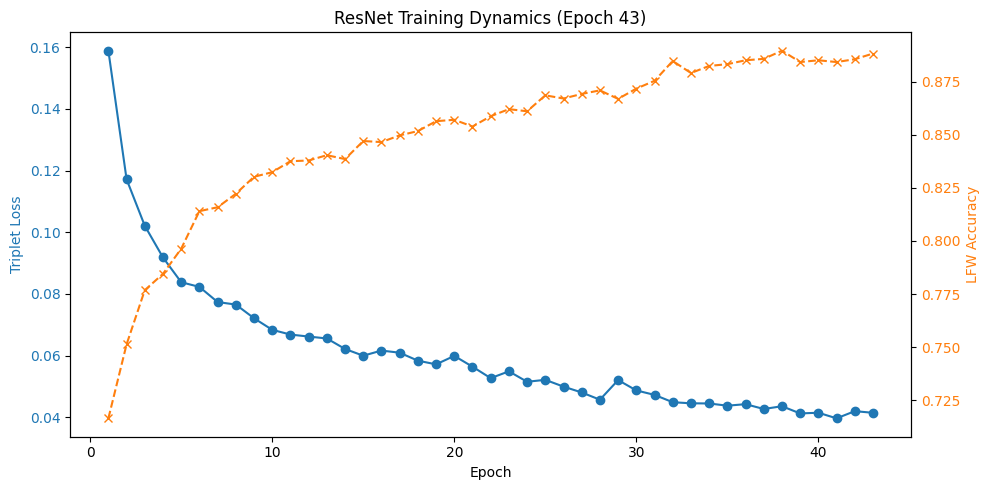

Epoch 43: Loss: 0.0414, Val Acc: 0.8882
EarlyStopping counter: 5 out of 5
Early stopping triggered! Model has stopped improving.
Loaded best ResNet model weights!
Visualizing Validation Pairs...


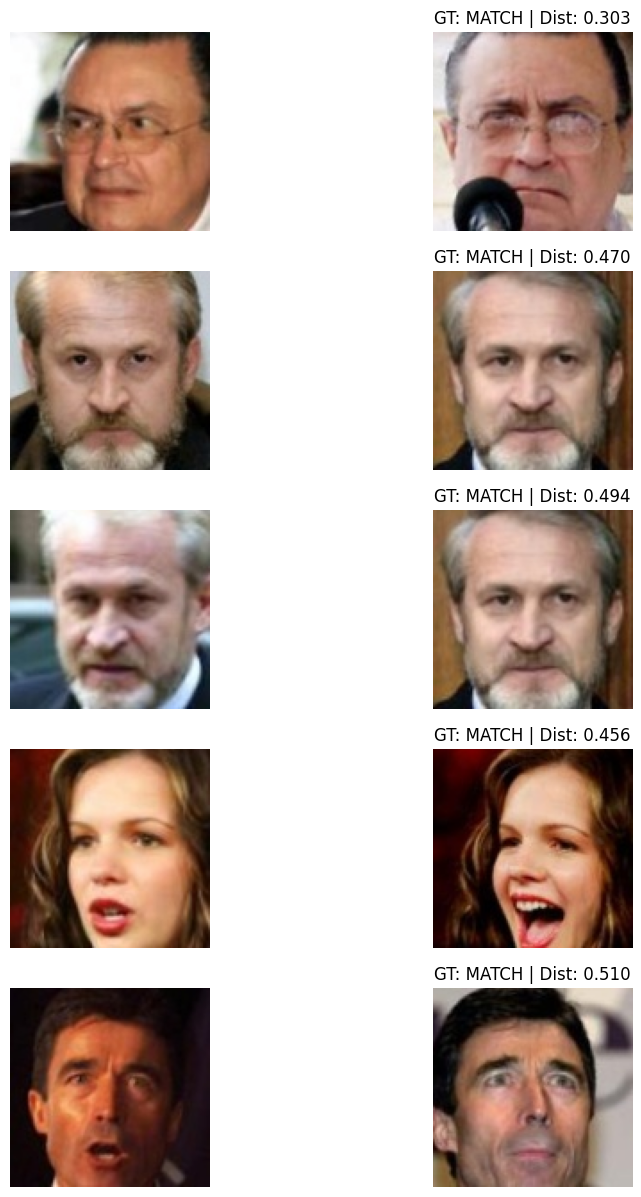

In [ ]:
import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from IPython.display import clear_output
from torch.utils.data import DataLoader

# --- UPDATED Hyperparameters ---
BATCH_SIZE = 32
LEARNING_RATE = 0.0001
EPOCHS = 100
EMBEDDING_DIM = 128
MARGIN = 0.2

# --- Setup ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 1. Re-initialize the Model (to start fresh)
SNN2 = SiameseNetwork_ResNet().to(device)

# 2. Define Optimizer AND Scheduler
optimizer = optim.Adam(SNN2.parameters(), lr=LEARNING_RATE)
criterion = nn.TripletMarginLoss(margin=MARGIN, p=2)

# --- FIX: Define the missing scheduler ---
# Reduce LR if the Loss stops dropping (patience=2 epochs)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

# 3. Reset Helpers
history = {'train_loss': [], 'val_acc': [], 'epochs': []}
early_stopper = EarlyStopping(patience=5, verbose=True)

print("Starting ResNet Training with validation monitoring...")

for epoch in range(EPOCHS):
    SNN2.train()
    total_loss = 0

    loop = tqdm.tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")

    for anchor, positive, negative in loop:
        anchor, positive, negative = anchor.to(device), positive.to(device), negative.to(device)

        optimizer.zero_grad()

        # Get embeddings
        a_emb, p_emb, n_emb = SNN2(anchor), SNN2(positive), SNN2(negative)

        # Calculate Loss
        loss = criterion(a_emb, p_emb, n_emb)

        # Backprop
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        loop.set_postfix(loss=loss.item())

    avg_train_loss = total_loss / len(train_loader)

    # VALIDATION PHASE
    val_acc = evaluate_lfw_accuracy(SNN2, lfw_loader, device)

    # Update History
    history['train_loss'].append(avg_train_loss)
    history['val_acc'].append(val_acc)
    history['epochs'].append(epoch+1)

    # Step the scheduler
    scheduler.step(avg_train_loss)

    # Live Plotting
    clear_output(wait=True)

    fig, ax1 = plt.subplots(figsize=(10, 5))

    # Plot Loss
    color = 'tab:blue'
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Triplet Loss', color=color)
    ax1.plot(history['epochs'], history['train_loss'], color=color, marker='o', label='Train Loss')
    ax1.tick_params(axis='y', labelcolor=color)

    # Plot Accuracy
    ax2 = ax1.twinx()
    color = 'tab:orange'
    ax2.set_ylabel('LFW Accuracy', color=color)
    ax2.plot(history['epochs'], history['val_acc'], color=color, marker='x', linestyle="--", label='Val Acc')
    ax2.tick_params(axis='y', labelcolor=color)

    plt.title(f"ResNet Training Dynamics (Epoch {epoch+1})")
    fig.tight_layout()
    plt.show()

    print(f"Epoch {epoch+1}: Loss: {avg_train_loss:.4f}, Val Acc: {val_acc:.4f}")

    # Early Stopping Check
    early_stopper(val_acc, SNN2, 'best_resnet_model.pth')

    if early_stopper.early_stop:
        print("Early stopping triggered! Model has stopped improving.")
        break

# Load Best Weights
SNN2.load_state_dict(torch.load('best_resnet_model.pth'))
print("Loaded best ResNet model weights!")

print("Visualizing Validation Pairs...")
visualize_validation_pairs(lfw_loader, SNN2, device)

### SNN + ViT

In [ ]:
# --- 3. ViT Architecture (ViT-B/16) ---
import timm
import torch.nn as nn

class SiameseNetwork_ViT(nn.Module):
    def __init__(self, embedding_dim=128):
        super(SiameseNetwork_ViT, self).__init__()
        # We use ViT-Base with Patch Size 16 (better detail than 32)
        # Pretrained on ImageNet-21k (diverse real-world images)
        self.backbone = timm.create_model('vit_base_patch16_224', pretrained=True, num_classes=0)

        # ViT-Base outputs 768 features (vs 512 for ResNet)
        self.classifier = nn.Sequential(
            nn.Linear(768, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Linear(512, embedding_dim)
        )

    def forward(self, x):
        # ViT expects 224x224 images. Our input is 112x112.
        # We must upscale carefully to preserve the "patch" structure.
        x = torch.nn.functional.interpolate(x, size=(224, 224), mode='bilinear', align_corners=False)

        features = self.backbone(x)
        embedding = self.classifier(features)
        return torch.nn.functional.normalize(embedding, p=2, dim=1)

### Training Loop (SNN+ViT)

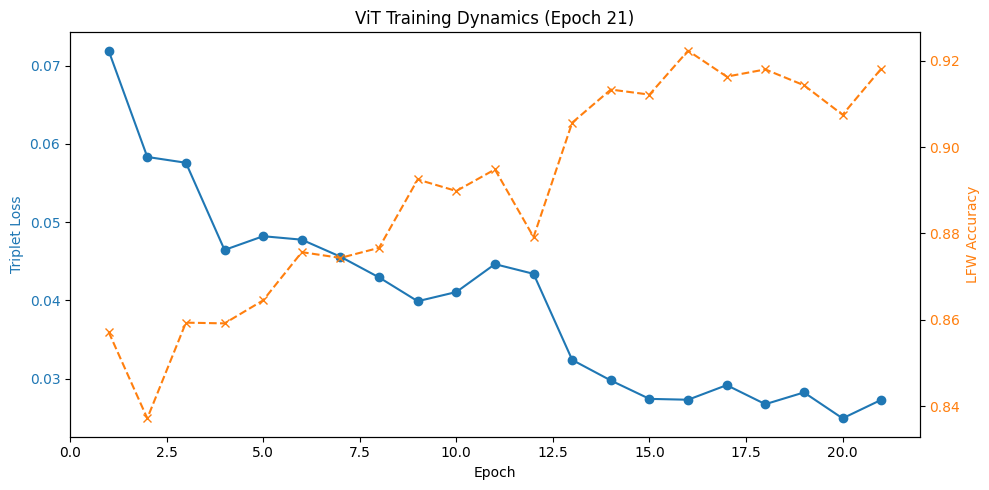

Epoch 21: Loss: 0.0273, Val Acc: 0.9182
EarlyStopping counter: 5 out of 5
Early stopping triggered! Model has stopped improving.
Loaded best ViT model weights!
Visualizing Validation Pairs...


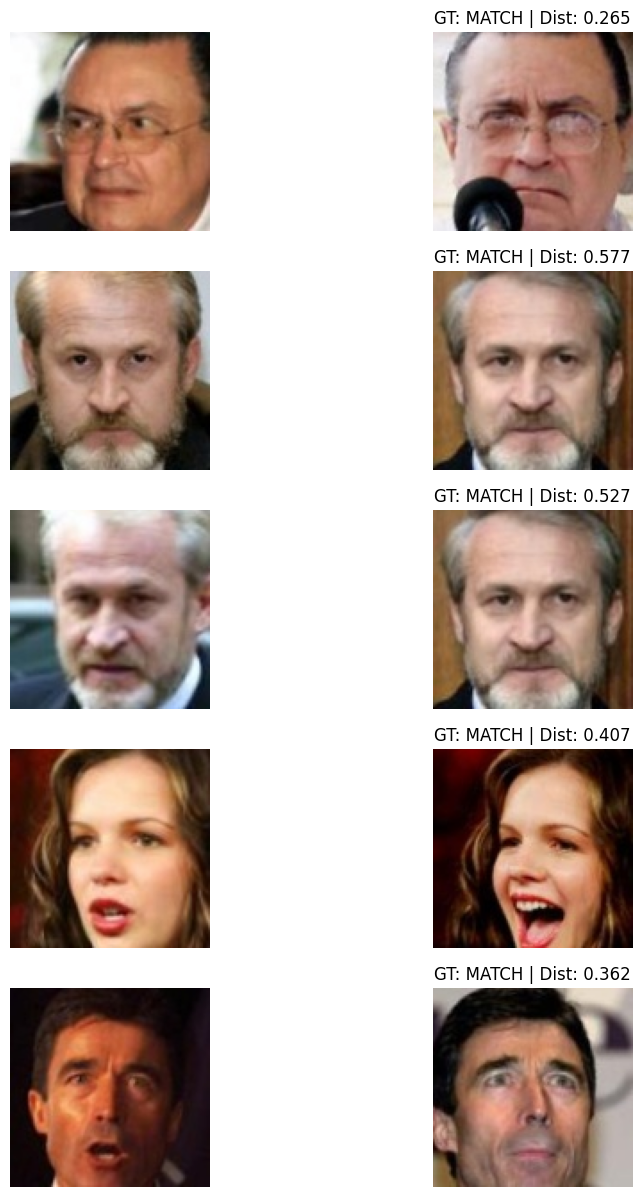

In [ ]:
import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from IPython.display import clear_output
from torch.utils.data import DataLoader

# --- HYPERPARAMETERS ---
EMBEDDING_DIM = 128
BATCH_SIZE = 16 # Tiny ViT
LEARNING_RATE = 0.0001
EPOCHS = 100
MARGIN = 0.2

# --- SETUP ---
# Stelle sicher, dass 'device' definiert ist
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 1. Modell neu initialisieren
SNN_ViT = SiameseNetwork_ViT(embedding_dim=EMBEDDING_DIM).to(device)

# 2. Optimizer & Loss & Scheduler
optimizer = optim.Adam(SNN_ViT.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
criterion = nn.TripletMarginLoss(margin=MARGIN, p=2)

# 3. Helpers Resetten
history = {'train_loss': [], 'val_acc': [], 'epochs': []}
early_stopper = EarlyStopping(patience=5, verbose=True)

print("Starting ViT Training with Validation Monitoring...")

for epoch in range(EPOCHS):
    SNN_ViT.train()
    total_loss = 0

    loop = tqdm.tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")

    for anchor, positive, negative in loop:
        anchor, positive, negative = anchor.to(device), positive.to(device), negative.to(device)

        optimizer.zero_grad()

        # Forward Pass
        a_emb = SNN_ViT(anchor)
        p_emb = SNN_ViT(positive)
        n_emb = SNN_ViT(negative)

        # Loss Calculation
        loss = criterion(a_emb, p_emb, n_emb)

        # Backward Pass
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        loop.set_postfix(loss=loss.item())

    avg_train_loss = total_loss / len(train_loader)

    # --- VALIDATION PHASE ---
    # Prüft Accuracy auf dem LFW Dataset
    val_acc = evaluate_lfw_accuracy(SNN_ViT, lfw_loader, device)

    # Update History
    history['train_loss'].append(avg_train_loss)
    history['val_acc'].append(val_acc)
    history['epochs'].append(epoch + 1)

    # Scheduler Step
    scheduler.step(avg_train_loss)

    # --- LIVE PLOTTING ---
    clear_output(wait=True)

    fig, ax1 = plt.subplots(figsize=(10, 5))

    # Plot Loss (Blau)
    color = 'tab:blue'
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Triplet Loss', color=color)
    ax1.plot(history['epochs'], history['train_loss'], color=color, marker='o', label='Train Loss')
    ax1.tick_params(axis='y', labelcolor=color)

    # Plot Accuracy (Orange)
    ax2 = ax1.twinx()
    color = 'tab:orange'
    ax2.set_ylabel('LFW Accuracy', color=color)
    ax2.plot(history['epochs'], history['val_acc'], color=color, marker='x', linestyle="--", label='Val Acc')
    ax2.tick_params(axis='y', labelcolor=color)

    plt.title(f"ViT Training Dynamics (Epoch {epoch+1})")
    fig.tight_layout()
    plt.show()

    print(f"Epoch {epoch+1}: Loss: {avg_train_loss:.4f}, Val Acc: {val_acc:.4f}")

    # --- EARLY STOPPING CHECK ---
    early_stopper(val_acc, SNN_ViT, 'best_vit_model.pth')

    if early_stopper.early_stop:
        print("Early stopping triggered! Model has stopped improving.")
        break

# Am Ende das beste Modell laden
SNN_ViT.load_state_dict(torch.load('best_vit_model.pth'))
print("Loaded best ViT model weights!")

print("Visualizing Validation Pairs...")
visualize_validation_pairs(lfw_loader, SNN_ViT, device)

## Evaluation

Starting Comparative Evaluation on LFW Dataset...
Evaluating EfficientNet-B0...
Evaluating ResNet-50...
Evaluating ViT-Tiny...


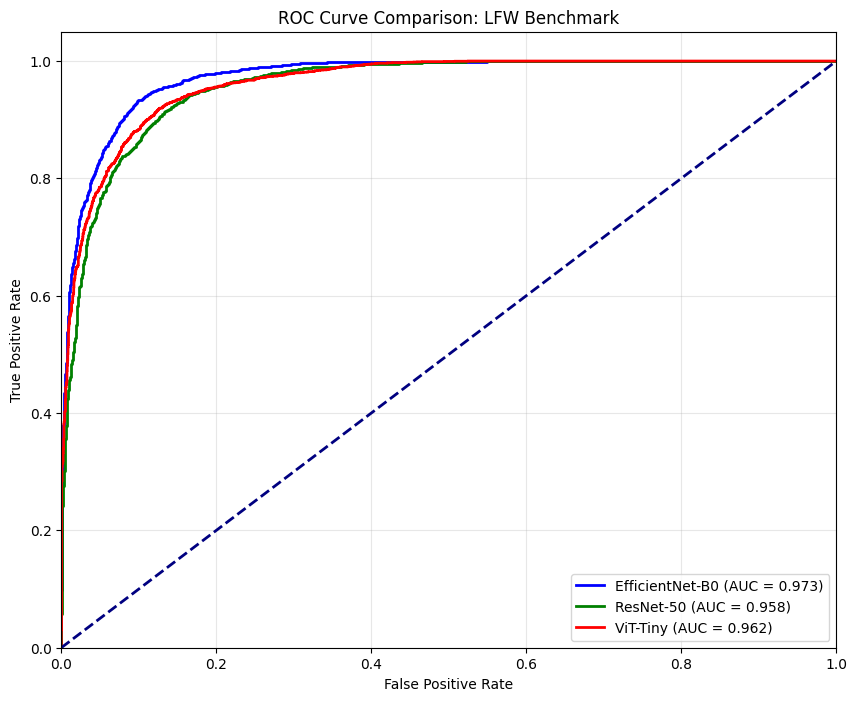


--- Final Comparative Results ---
             Model  LFW Accuracy   LFW AUC
0  EfficientNet-B0      0.914833  0.972861
1        ResNet-50      0.889500  0.957830
2         ViT-Tiny      0.894500  0.962285


In [ ]:
# --- Comparative Analysis: EfficientNet vs ResNet vs ViT ---
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, auc

# Define locations of saved weights (Ensure you have trained all 3!)
# You need to run a training loop for ViT similar to the others before running this
MODELS_TO_COMPARE = {
    "EfficientNet-B0": {
        "class": SiameseNetwork_EffNet,
        "path": "/content/best_effnet_model.pth", # Update filename if needed
        "color": "blue"
    },
    "ResNet-50": {
        "class": SiameseNetwork_ResNet,
        "path": "/content/best_resnet_model.pth",
        "color": "green"
    },
    "ViT-Tiny": {
        "class": SiameseNetwork_ViT,
        "path": "/content/best_vit_model.pth", # You need to train this first!
        "color": "red"
    }
}

results_table = []
plt.figure(figsize=(10, 8))

print("Starting Comparative Evaluation on LFW Dataset...")

for model_name, config in MODELS_TO_COMPARE.items():
    print(f"Evaluating {model_name}...")

    # 1. Load Model
    try:
        model = config["class"]().to(device)
        model.load_state_dict(torch.load(config["path"]))
        model.eval()
    except FileNotFoundError:
        print(f"⚠️ Skip: Weights not found for {model_name} at {config['path']}")
        continue

    # 2. Get Distances
    distances = []
    labels = []

    with torch.no_grad():
        for img1, img2, label in lfw_loader:
            img1, img2 = img1.to(device), img2.to(device)
            emb1 = model(img1)
            emb2 = model(img2)
            dist = torch.nn.functional.pairwise_distance(emb1, emb2)
            distances.extend(dist.cpu().numpy())
            labels.extend(label.numpy())

    distances = np.array(distances)
    labels = np.array(labels)

    # 3. Calculate Metrics
    # Find best threshold for Accuracy
    best_acc = 0
    for thresh in np.arange(0.5, 1.5, 0.05):
        preds = (distances < thresh).astype(int)
        acc = accuracy_score(labels, preds)
        if acc > best_acc: best_acc = acc

    # AUC
    # Note: distance is 'lower is better', labels are 1 for match.
    # We invert distances (-distances) for ROC calculation
    fpr, tpr, _ = roc_curve(labels, -distances)
    roc_auc = auc(fpr, tpr)

    results_table.append({
        "Model": model_name,
        "LFW Accuracy": best_acc,
        "LFW AUC": roc_auc
    })

    # 4. Plot ROC
    plt.plot(fpr, tpr, color=config["color"], lw=2, label=f'{model_name} (AUC = {roc_auc:.3f})')

# Finalize Plot
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison: LFW Benchmark')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# Show Table
df_results = pd.DataFrame(results_table)
print("\n--- Final Comparative Results ---")
print(df_results)

## Phase 3: ArcFace+FineTuning

TripletLoss learns by comparing 3 images (Anchor, Pos, Neg). ArcFace learns by Classification (predicting "Who is this?"). It forces the features on the hypersphere to be super compact.

This requires 3 changes:
- New Dataset Class: We stop generating triplets and just return Image,Label ID.

- New Loss Layer: We add the ArcMarginProduct layer.

- New Loop: We train using CrossEntropyLoss but modified by ArcFace.

In [ ]:
# MS-CELEB-1M
import kagglehub

# Download latest version
path = kagglehub.dataset_download("yakhyokhuja/ms1m-arcface-dataset")

print("Path to dataset files:", path)

100%|██████████| 15.5G/15.5G [02:59<00:00, 92.8MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/yakhyokhuja/ms1m-arcface-dataset/versions/1


In [ ]:
from torchvision.datasets import ImageFolder
import os
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as transforms

# Standard ImageFolder works perfectly fine for ArcFace because it returns (Image, Class_Index)
# We just wrap it to add our specific face transforms

class FaceLabelDataset(Dataset):
    def __init__(self, root_dir):
        # We use 'transform' (singular) variable name to match PyTorch convention
        self.transform = transforms.Compose([
            transforms.Resize((112, 112)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

        # ERROR WAS HERE: changed 'transforms=' to 'transform='
        self.dataset = ImageFolder(root=root_dir, transform=self.transform)
        self.classes = self.dataset.classes
        print(f"✅ Loaded {len(self.classes)} identities for ArcFace Training.")

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        return self.dataset[idx]

In [ ]:
import math
import torch.nn.functional as F

class ArcFaceLayer(nn.Module):
    def __init__(self, embedding_dim=128, num_classes=1000, s=30.0, m=0.50):
        super(ArcFaceLayer, self).__init__()
        self.s = s  # Scale factor
        self.m = m  # Margin

        # This weight matrix stores the "center" vector for every identity
        self.weight = nn.Parameter(torch.FloatTensor(num_classes, embedding_dim))
        nn.init.xavier_uniform_(self.weight)

    def forward(self, features, labels):
        # 1. Normalize Weights and Features (Project to Hypersphere)
        cosine = F.linear(F.normalize(features), F.normalize(self.weight))

        # 2. Convert Cosine to Angle (Theta)
        theta = torch.acos(torch.clamp(cosine, -1.0 + 1e-7, 1.0 - 1e-7))

        # 3. Add Margin to the Angle of the "Correct" Class
        # This pushes the class center further away from others
        one_hot = torch.zeros_like(cosine)
        one_hot.scatter_(1, labels.view(-1, 1), 1.0)

        target_logit = torch.cos(theta + self.m)

        # 4. Recombine
        output = (one_hot * target_logit) + ((1.0 - one_hot) * cosine)

        # 5. Rescale
        output *= self.s
        return output

### Fine-tune SSN (EfficientNet)

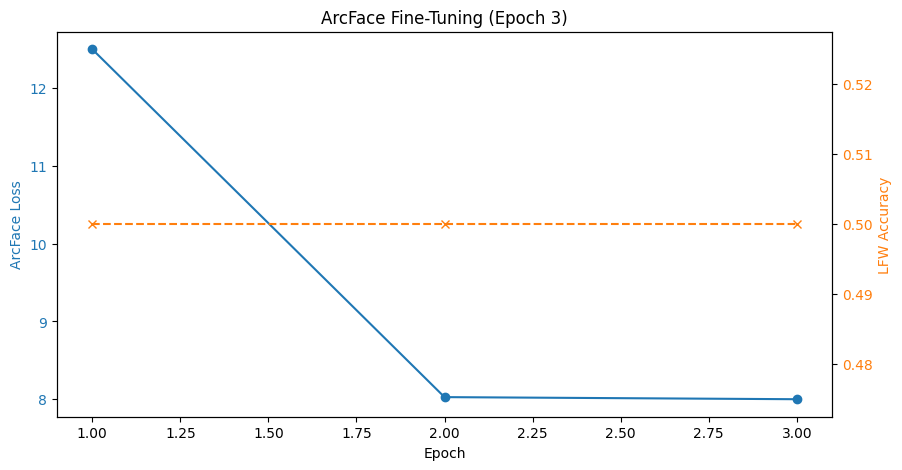

Epoch 3 :: Loss: 8.0010 | LFW Acc: 0.5000
Validation Accuracy increased (0.5000 --> 0.5000).  Saving model ...


Epoch 4/20:   1%|          | 463/90979 [00:32<1:45:10, 14.34it/s, loss=7.95]


KeyboardInterrupt: 

In [ ]:
import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from IPython.display import clear_output
from torch.utils.data import DataLoader

# --- CONFIGURATION ---
FINE_TUNE_LR = 0.00001   # Very low LR to preserve pre-trained features
ARCFACE_EPOCHS = 20      # Fine-tuning is faster
NUM_CLASSES = 85742      # MS1M-ArcFace Identity Count (Change if using VGGFace2)
EMBEDDING_DIM = 128
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Prepare Data
# We use the LabelDataset for ArcFace (Image, ClassID)
# Ensure you point this to your MS1M or VGGFace2 folder
arcface_dataset = FaceLabelDataset(root_dir="/root/.cache/kagglehub/datasets/yakhyokhuja/ms1m-arcface-dataset/versions/1/ms1m-arcface")
arcface_loader = DataLoader(arcface_dataset, batch_size=64, shuffle=True, num_workers=2)

# 2. Load Your Best Triplet Model (e.g., ResNet)
model = SiameseNetwork_EffNet().to(DEVICE)
# Load the weights you trained in Phase 2
model.load_state_dict(torch.load("/content/best_effnet_model.pth"))
print("✅ Loaded Best Triplet Weights.")

# 3. Initialize ArcFace Layer
metric_fc = ArcFaceLayer(embedding_dim=128, num_classes=NUM_CLASSES).to(DEVICE)

# 4. Optimizer (Optimizes Backbone AND ArcFace Centers)
optimizer = optim.Adam([
    {'params': model.parameters()},
    {'params': metric_fc.parameters()}
], lr=FINE_TUNE_LR)

criterion = nn.CrossEntropyLoss()
early_stopper = EarlyStopping(patience=3, verbose=True)
history = {'train_loss': [], 'val_acc': [], 'epochs': []}

print(f"🚀 Starting ArcFace Fine-Tuning on {NUM_CLASSES} classes...")

for epoch in range(ARCFACE_EPOCHS):
    model.train()
    metric_fc.train()
    total_loss = 0

    loop = tqdm.tqdm(arcface_loader, desc=f"Epoch {epoch+1}/{ARCFACE_EPOCHS}")

    for images, labels in loop:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()

        # 1. Get Features
        features = model(images)

        # 2. ArcFace Margin
        outputs = metric_fc(features, labels)

        # 3. Cross Entropy
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        loop.set_postfix(loss=loss.item())

    avg_loss = total_loss / len(arcface_loader)

    # --- VALIDATION (LFW) ---
    # We check if the embeddings are getting better at separation
    val_acc = evaluate_lfw_accuracy(model, lfw_loader, DEVICE)

    # Update History
    history['train_loss'].append(avg_loss)
    history['val_acc'].append(val_acc)
    history['epochs'].append(epoch + 1)

    # --- LIVE PLOTTING ---
    clear_output(wait=True)
    fig, ax1 = plt.subplots(figsize=(10, 5))

    color = 'tab:blue'
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('ArcFace Loss', color=color)
    ax1.plot(history['epochs'], history['train_loss'], color=color, marker='o', label='Train Loss')
    ax1.tick_params(axis='y', labelcolor=color)

    ax2 = ax1.twinx()
    color = 'tab:orange'
    ax2.set_ylabel('LFW Accuracy', color=color)
    ax2.plot(history['epochs'], history['val_acc'], color=color, marker='x', linestyle="--", label='Val Acc')
    ax2.tick_params(axis='y', labelcolor=color)

    plt.title(f"ArcFace Fine-Tuning (Epoch {epoch+1})")
    plt.show()

    print(f"Epoch {epoch+1} :: Loss: {avg_loss:.4f} | LFW Acc: {val_acc:.4f}")

    # Early Stopping
    early_stopper(val_acc, model, "best_arcface_effnet.pth")
    if early_stopper.early_stop:
        print("Stopping early.")
        break

# Load Best Fine-Tuned Weights
model.load_state_dict(torch.load("best_arcface_effnet.pth"))
print("✅ Fine-Tuning Complete. Loaded best ArcFace model.")

In [ ]:
from google.colab import drive
import shutil

# 1. Mount Drive
drive.mount('/content/drive')

# 2. Copy the latest checkpoint to Drive (Safety Backup)
# Change '3' to whatever epoch finished last
shutil.copy("best_arcface_effnet.pth", "/content/drive/MyDrive/best_arcface_effnet.pth")

print("✅ Saved Epoch 3 to Google Drive! You are safe.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Saved Epoch 3 to Google Drive! You are safe.


Running Comparative Evaluation...


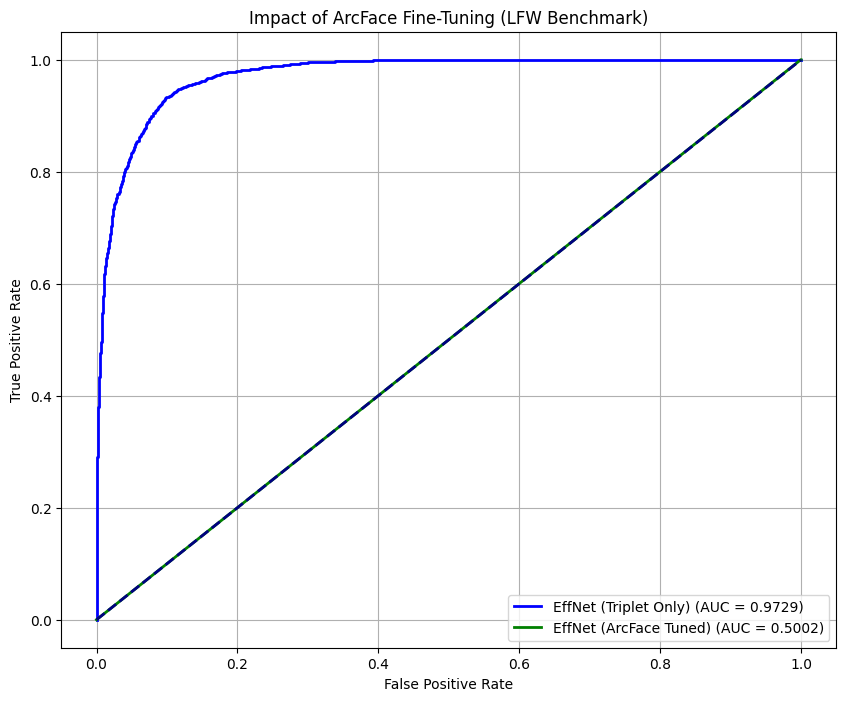

In [ ]:
# EVALUATION
from sklearn.metrics import roc_curve, auc

# 1. Define Models to Compare
# We compare the Triplet-only model vs. the ArcFace-tuned model
models_to_test = {
    "EffNet (Triplet Only)": {
        "model": SiameseNetwork_EffNet().to(DEVICE),
        "path": "best_effnet_model.pth",  # From Phase 2
        "color": "blue"
    },
    "EffNet (ArcFace Tuned)": {
        "model": SiameseNetwork_EffNet().to(DEVICE),
        "path": "best_arcface_effnet.pth", # From Phase 3
        "color": "green"
    }
}

plt.figure(figsize=(10, 8))
print("Running Comparative Evaluation...")

for name, config in models_to_test.items():
    # Load Weights
    try:
        config["model"].load_state_dict(torch.load(config["path"]))
    except:
        print(f"⚠️ Missing weights for {name}")
        continue

    config["model"].eval()
    distances = []
    labels = []

    with torch.no_grad():
        for img1, img2, label in lfw_loader:
            img1, img2 = img1.to(DEVICE), img2.to(DEVICE)
            emb1 = config["model"](img1)
            emb2 = config["model"](img2)
            dist = torch.nn.functional.pairwise_distance(emb1, emb2)
            distances.extend(dist.cpu().numpy())
            labels.extend(label.numpy())

    # Calculate ROC
    # Note: We use -distances because smaller distance = higher similarity
    fpr, tpr, _ = roc_curve(labels, -np.array(distances))
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, color=config["color"], lw=2, label=f'{name} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Impact of ArcFace Fine-Tuning (LFW Benchmark)')
plt.legend(loc="lower right")
plt.grid(True)
plt.savefig("arcface_improvement_roc.png") # Save for presentation
plt.show()

In [ ]:
print("Visualizing ArcFace Predictions on LFW...")
# Load the ArcFace model explicitly
arcface_model = SiameseNetwork_ResNet().to(DEVICE)
arcface_model.load_state_dict(torch.load("best_arcface_effnet.pth"))

visualize_validation_pairs(lfw_loader, arcface_model, DEVICE, num_pairs=6)

Visualizing ArcFace Predictions on LFW...
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 184MB/s]


RuntimeError: Error(s) in loading state_dict for SiameseNetwork_ResNet:
	Missing key(s) in state_dict: "backbone.conv1.weight", "backbone.bn1.weight", "backbone.bn1.bias", "backbone.bn1.running_mean", "backbone.bn1.running_var", "backbone.layer1.0.conv1.weight", "backbone.layer1.0.bn1.weight", "backbone.layer1.0.bn1.bias", "backbone.layer1.0.bn1.running_mean", "backbone.layer1.0.bn1.running_var", "backbone.layer1.0.conv2.weight", "backbone.layer1.0.bn2.weight", "backbone.layer1.0.bn2.bias", "backbone.layer1.0.bn2.running_mean", "backbone.layer1.0.bn2.running_var", "backbone.layer1.0.conv3.weight", "backbone.layer1.0.bn3.weight", "backbone.layer1.0.bn3.bias", "backbone.layer1.0.bn3.running_mean", "backbone.layer1.0.bn3.running_var", "backbone.layer1.0.downsample.0.weight", "backbone.layer1.0.downsample.1.weight", "backbone.layer1.0.downsample.1.bias", "backbone.layer1.0.downsample.1.running_mean", "backbone.layer1.0.downsample.1.running_var", "backbone.layer1.1.conv1.weight", "backbone.

### Fine-tune SNN (ResNet-50)

In [ ]:
import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from IPython.display import clear_output
from torch.utils.data import DataLoader

# --- CONFIGURATION ---
FINE_TUNE_LR = 0.00001   # Very low LR to preserve pre-trained features
ARCFACE_EPOCHS = 20      # Fine-tuning is faster
NUM_CLASSES = 85742      # MS1M-ArcFace Identity Count (Change if using VGGFace2)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Prepare Data
# We use the LabelDataset for ArcFace (Image, ClassID)
# Ensure you point this to your MS1M or VGGFace2 folder
arcface_dataset = FaceLabelDataset(root_dir="/root/.cache/kagglehub/datasets/yakhyokhuja/ms1m-arcface-dataset/versions/1/ms1m-arcface")
arcface_loader = DataLoader(arcface_dataset, batch_size=64, shuffle=True, num_workers=2)

# 2. Load Your Best Triplet Model (e.g., ResNet)
model = SiameseNetwork_ResNet().to(DEVICE)
# Load the weights you trained in Phase 2
model.load_state_dict(torch.load("/content/best_resnet_model.pth"))
print("✅ Loaded Best Triplet Weights.")

# 3. Initialize ArcFace Layer
metric_fc = ArcFaceLayer(embedding_dim=128, num_classes=NUM_CLASSES).to(DEVICE)

# 4. Optimizer (Optimizes Backbone AND ArcFace Centers)
optimizer = optim.Adam([
    {'params': model.parameters()},
    {'params': metric_fc.parameters()}
], lr=FINE_TUNE_LR)

criterion = nn.CrossEntropyLoss()
early_stopper = EarlyStopping(patience=3, verbose=True)
history = {'train_loss': [], 'val_acc': [], 'epochs': []}

print(f"🚀 Starting ArcFace Fine-Tuning on {NUM_CLASSES} classes...")

for epoch in range(ARCFACE_EPOCHS):
    model.train()
    metric_fc.train()
    total_loss = 0

    loop = tqdm.tqdm(arcface_loader, desc=f"Epoch {epoch+1}/{ARCFACE_EPOCHS}")

    for images, labels in loop:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()

        # 1. Get Features
        features = model(images)

        # 2. ArcFace Margin
        outputs = metric_fc(features, labels)

        # 3. Cross Entropy
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        loop.set_postfix(loss=loss.item())

    avg_loss = total_loss / len(arcface_loader)

    # --- VALIDATION (LFW) ---
    # We check if the embeddings are getting better at separation
    val_acc = evaluate_lfw_accuracy(model, lfw_loader, DEVICE)

    # Update History
    history['train_loss'].append(avg_loss)
    history['val_acc'].append(val_acc)
    history['epochs'].append(epoch + 1)

    # --- LIVE PLOTTING ---
    clear_output(wait=True)
    fig, ax1 = plt.subplots(figsize=(10, 5))

    color = 'tab:blue'
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('ArcFace Loss', color=color)
    ax1.plot(history['epochs'], history['train_loss'], color=color, marker='o', label='Train Loss')
    ax1.tick_params(axis='y', labelcolor=color)

    ax2 = ax1.twinx()
    color = 'tab:orange'
    ax2.set_ylabel('LFW Accuracy', color=color)
    ax2.plot(history['epochs'], history['val_acc'], color=color, marker='x', linestyle="--", label='Val Acc')
    ax2.tick_params(axis='y', labelcolor=color)

    plt.title(f"ArcFace Fine-Tuning (Epoch {epoch+1})")
    plt.show()

    print(f"Epoch {epoch+1} :: Loss: {avg_loss:.4f} | LFW Acc: {val_acc:.4f}")

    # Early Stopping
    early_stopper(val_acc, model, "best_arcface_resnet.pth")
    if early_stopper.early_stop:
        print("Stopping early.")
        break

# Load Best Fine-Tuned Weights
model.load_state_dict(torch.load("best_arcface_resnet.pth"))
print("✅ Fine-Tuning Complete. Loaded best ArcFace model.")

✅ Loaded 85742 identities for ArcFace Training.
✅ Loaded Best Triplet Weights.
🚀 Starting ArcFace Fine-Tuning on 85742 classes...


Epoch 1/20:  54%|█████▍    | 49260/90979 [1:51:54<1:34:39,  7.35it/s, loss=8.09]

In [ ]:
# EVALUATION
from sklearn.metrics import roc_curve, auc

# 1. Define Models to Compare
# We compare the Triplet-only model vs. the ArcFace-tuned model
models_to_test = {
    "ResNet (Triplet Only)": {
        "model": SiameseNetwork_ResNet().to(DEVICE),
        "path": "best_resnet_model.pth",  # From Phase 2
        "color": "blue"
    },
    "ResNet (ArcFace Tuned)": {
        "model": SiameseNetwork_ResNet().to(DEVICE),
        "path": "best_arcface_resnet.pth", # From Phase 3
        "color": "green"
    }
}

plt.figure(figsize=(10, 8))
print("Running Comparative Evaluation...")

for name, config in models_to_test.items():
    # Load Weights
    try:
        config["model"].load_state_dict(torch.load(config["path"]))
    except:
        print(f"⚠️ Missing weights for {name}")
        continue

    config["model"].eval()
    distances = []
    labels = []

    with torch.no_grad():
        for img1, img2, label in lfw_loader:
            img1, img2 = img1.to(DEVICE), img2.to(DEVICE)
            emb1 = config["model"](img1)
            emb2 = config["model"](img2)
            dist = torch.nn.functional.pairwise_distance(emb1, emb2)
            distances.extend(dist.cpu().numpy())
            labels.extend(label.numpy())

    # Calculate ROC
    # Note: We use -distances because smaller distance = higher similarity
    fpr, tpr, _ = roc_curve(labels, -np.array(distances))
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, color=config["color"], lw=2, label=f'{name} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Impact of ArcFace Fine-Tuning (LFW Benchmark)')
plt.legend(loc="lower right")
plt.grid(True)
plt.savefig("arcface_improvement_roc.png") # Save for presentation
plt.show()

In [ ]:
print("Visualizing ArcFace Predictions on LFW...")
# Load the ArcFace model explicitly
arcface_model = SiameseNetwork_ResNet().to(DEVICE)
arcface_model.load_state_dict(torch.load("best_arcface_resnet.pth"))

visualize_validation_pairs(lfw_loader, arcface_model, DEVICE, num_pairs=6)

### Fine-tune SNN (ViT)